# Summary Statistics

Center: Where is the middle? (Mean, Weighted Mean, Median, Mode)

Spread: How wide is the variation? (Range, Percentiles, IQR, Variance, Standard Deviation)

Shape: What does it look like? (Histograms, Normal Curves, Bimodal Splits, Skew, Outliers)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-colorblind")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

## The dataset

Read the data and look at the first few rows.

In [16]:
df = pd.read_csv("students.csv")
df.head(10)

,student_id,section,exam_score,quiz_score,study_hours,attendance,commute_min,section_score
0,1,A,76.8,30.1,7.2,8,11,85.8
1,2,B,61.1,86.0,11.5,8,16,50.4
2,3,B,67.5,67.5,7.8,9,25,68.7
3,4,A,87.6,64.5,7.3,13,21,81.6
4,5,A,67.7,84.4,8.2,11,19,80.0
5,6,B,80.9,76.2,2.5,11,17,67.5
6,7,A,60.8,68.9,9.0,16,16,77.2
7,8,B,69.5,85.4,4.0,9,19,57.8
8,9,A,60.6,64.5,4.1,19,17,85.6
9,10,A,67.9,90.8,5.3,17,18,82.9


### Student Dataset

200 students, one row each.

| column | meaning |
|---|---|
| `student_id` | row identifier |
| `section` | which lecture section the student is in (`A` or `B`) |
| `exam_score` | final exam score, 0-100 |
| `quiz_score` | average quiz score for the term, 0-100 |
| `study_hours` | self-reported hours studied per week |
| `attendance` | classes attended, out of 20 |
| `commute_min` | one-way commute to campus, in minutes |
| `section_score` | score on a section-specific assessment, 0-100 |

`df.describe()` gives a first summary of every numeric column: count, mean, standard
deviation, min, the quartiles, and max. Almost every statistic in this notebook appears
somewhere in that table.

In [17]:
df.describe()

,student_id,exam_score,quiz_score,study_hours,attendance,commute_min,section_score
count,200.000000,200.00000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,100.500000,71.53900,76.690500,5.995500,13.230000,19.88500,68.469000
std,57.879185,11.72023,15.614742,4.132276,4.320932,15.54445,12.533735
min,1.000000,41.20000,30.100000,0.200000,6.000000,6.00000,42.400000
25%,50.750000,63.30000,67.475000,2.875000,9.000000,14.75000,58.025000
50%,100.500000,70.70000,79.500000,5.100000,13.000000,17.50000,69.400000
75%,150.250000,77.20000,89.250000,8.275000,17.000000,21.00000,80.300000
max,200.000000,100.00000,99.400000,20.300000,20.000000,120.00000,90.900000


---
# 1. Central tendency

## Mean (arithmetic average)

Add up every value and divide by how many there are.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

```python
df["exam_score"].mean()          # or  np.mean(x)
```

The mean uses every data point, which also makes it **sensitive to outliers**: one extreme
value pulls it. It works best for roughly symmetric data.

In [18]:
x = df["exam_score"]

print(f"mean exam score: {x.mean():.1f}")

mean exam score: 71.5


A histogram of `exam_score` with the mean drawn on it. The mean sits near the middle of a
roughly symmetric distribution.

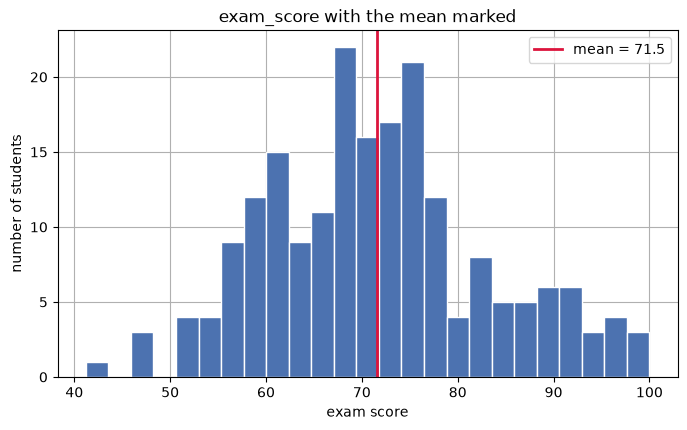

In [19]:
plt.hist(x, bins=25, color="#4C72B0", edgecolor="white")
plt.axvline(x.mean(), color="crimson", linewidth=2, label=f"mean = {x.mean():.1f}")
plt.title("exam_score with the mean marked")
plt.xlabel("exam score"); plt.ylabel("number of students"); plt.legend()
plt.show()

## Weighted mean

An average where some values count more than others. Each value $x_i$ is multiplied by a
weight $w_i$.

$$\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$$

```python
np.average(scores, weights=weights)
```

The usual example is a course grade assembled from parts that are worth different
percentages. The table below has a score for each component and the weight it carries.

In [20]:
grades = pd.DataFrame({
    "component": ["Homework", "Quizzes", "Midterm", "Final"],
    "score":     [88, 74, 65, 80],
    "weight":    [0.10, 0.20, 0.30, 0.40],   # weights sum to 1.0
})
grades

,component,score,weight
0,Homework,88,0.1
1,Quizzes,74,0.2
2,Midterm,65,0.3
3,Final,80,0.4


Compare the weighted mean to the plain mean, which wrongly treats 10%-homework and
40%-final as equally important.

In [21]:
weighted = np.average(grades["score"], weights=grades["weight"])
plain    = grades["score"].mean()

print(f"weighted mean: {weighted:.1f}")
print(f"plain mean   : {plain:.1f}   (ignores the weights)")

weighted mean: 75.1
plain mean   : 76.8   (ignores the weights)


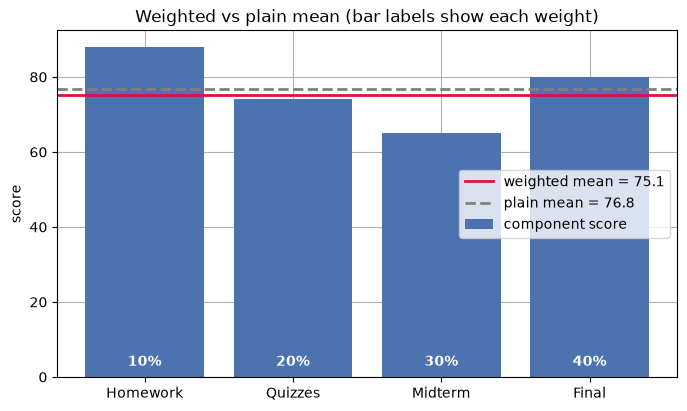

In [22]:
plt.bar(grades["component"], grades["score"], color="#4C72B0", label="component score")
plt.axhline(weighted, color="crimson", linewidth=2, label=f"weighted mean = {weighted:.1f}")
plt.axhline(plain, color="gray", linestyle="--", linewidth=2, label=f"plain mean = {plain:.1f}")
for i, wt in enumerate(grades["weight"]):
    plt.text(i, 3, f"{wt:.0%}", ha="center", color="white", fontweight="bold")
plt.title("Weighted vs plain mean (bar labels show each weight)")
plt.ylabel("score"); plt.legend()
plt.show()

## Median

Sort the values; the median is the one in the middle (or the average of the two middle
values if there is an even count). It is the 50th percentile.

```python
df["study_hours"].median()       # or  np.median(x)
```

The median only depends on the order of the data, not on how far away the extreme values
are, so it is **robust**: outliers barely move it. For skewed data (income, house prices,
wait times) it describes the "typical" value better than the mean.

`study_hours` has a long right tail, so its mean is noticeably higher than its median.

In [23]:
h = df["study_hours"]

print(f"median study hours: {h.median():.1f}")
print(f"mean study hours  : {h.mean():.1f}   (higher: pulled up by the long tail)")

median study hours: 5.1
mean study hours  : 6.0   (higher: pulled up by the long tail)


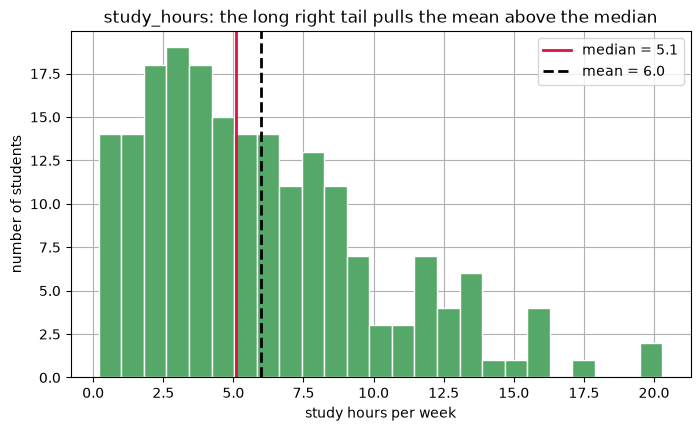

In [24]:
plt.hist(h, bins=25, color="#55A868", edgecolor="white")
plt.axvline(h.median(), color="crimson", linewidth=2, label=f"median = {h.median():.1f}")
plt.axvline(h.mean(), color="black", linestyle="--", linewidth=2, label=f"mean = {h.mean():.1f}")
plt.title("study_hours: the long right tail pulls the mean above the median")
plt.xlabel("study hours per week"); plt.ylabel("number of students"); plt.legend()
plt.show()

## Mode

The value that occurs most often. A dataset can have one mode, several, or no useful mode.

```python
df["attendance"].mode()          # returns every most-common value
```

The mode is the only measure of center that also works for **categories** (the most common
`section`, the most common major). For a continuous variable it usually just means "the
tallest bar of the histogram".

In [25]:
a = df["attendance"]
counts = a.value_counts().sort_index()

print(counts.to_string())
print()
print(f"mode of attendance : {a.mode().tolist()}")
print(f"most common section: {df['section'].mode()[0]}")

attendance
6     10
7     10
8     18
9     17
10     8
11    13
12    16
13    12
14    10
15    12
16    13
17    21
18    12
19    13
20    15

mode of attendance : [17]
most common section: B


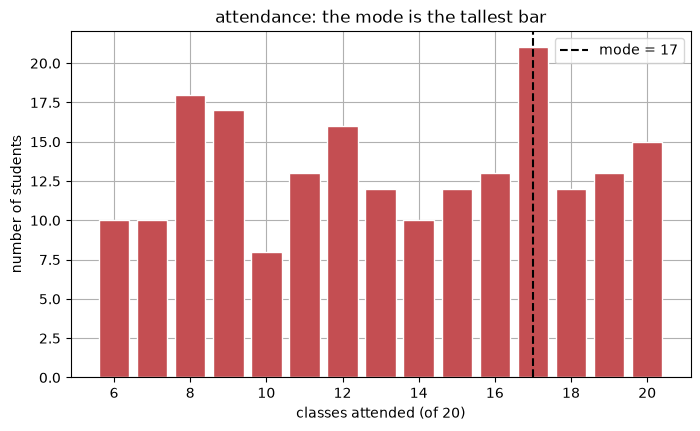

In [26]:
plt.bar(counts.index, counts.values, color="#C44E52", edgecolor="white")
plt.axvline(a.mode()[0], color="black", linestyle="--", label=f"mode = {a.mode()[0]}")
plt.title("attendance: the mode is the tallest bar")
plt.xlabel("classes attended (of 20)"); plt.ylabel("number of students"); plt.legend()
plt.show()

---
# 2. Spread

## Range

The distance from the smallest value to the largest.

$$\text{range} = \max(x) - \min(x)$$

```python
np.ptp(df["commute_min"])
```

It is the simplest measure of spread, but it depends only on the two most extreme points,
so a single unusual value can make it huge and misleading, as it does for `commute_min`.

In [27]:
c = df["commute_min"].to_numpy()

print(f"min   : {c.min()}")
print(f"max   : {c.max()}")
print(f"range : {np.ptp(c)}")

min   : 6
max   : 120
range : 114


## Percentile

The $p$-th percentile is the value below which $p\%$ of the data falls. If the 25th
percentile of `exam_score` is 63, a quarter of students scored below 63.

```python
np.percentile(df["exam_score"], 90)
```

Percentiles are how "top 10%" cutoffs, growth charts, and service targets like "95th
percentile response time" are defined. The median is just the 50th percentile.

In [28]:
pct = [2, 3, 4, 5, 5, 7, 8, 9, 10, 25]

print(f"25th percentile of dataset : {np.percentile(pct, 25):.1f}")
print(f"75th percentile of dataset : {np.percentile(pct, 75):.1f}")

25th percentile of dataset : 4.2
75th percentile of dataset : 8.8


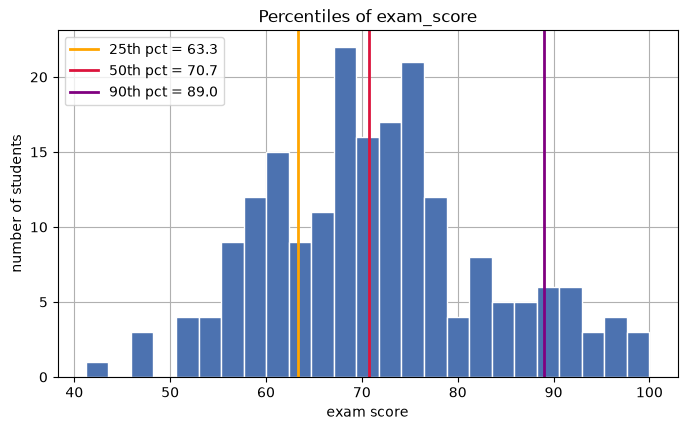

In [29]:
plt.hist(x, bins=25, color="#4C72B0", edgecolor="white")
for p, col in [(25, "orange"), (50, "crimson"), (90, "purple")]:
    plt.axvline(np.percentile(x, p), color=col, linewidth=2,
                label=f"{p}th pct = {np.percentile(x, p):.1f}")
plt.title("Percentiles of exam_score")
plt.xlabel("exam score"); plt.ylabel("number of students"); plt.legend()
plt.show()

## IQR (interquartile range)

The spread of the **middle 50%** of the data: the 75th percentile ($Q_3$) minus the 25th
($Q_1$).

$$\text{IQR} = Q_3 - Q_1$$

```python
q1, q3 = np.percentile(df["commute_min"], [25, 75])
iqr = q3 - q1
```

Because it ignores the top and bottom quarters, the IQR is not affected by outliers. It is
the length of the box in a box plot, and the basis of the standard rule for flagging
outliers (below). Compare the IQR of `commute_min` to its range.

In [30]:
q1, q3 = np.percentile(c, [25, 75])

print(f"Q1 (25th pct) : {q1:.1f}")
print(f"Q3 (75th pct) : {q3:.1f}")
print(f"IQR           : {q3 - q1:.1f}")
print(f"range         : {np.ptp(c):.1f}   (much larger: driven by the extremes)")

Q1 (25th pct) : 14.8
Q3 (75th pct) : 21.0
IQR           : 6.2
range         : 114.0   (much larger: driven by the extremes)


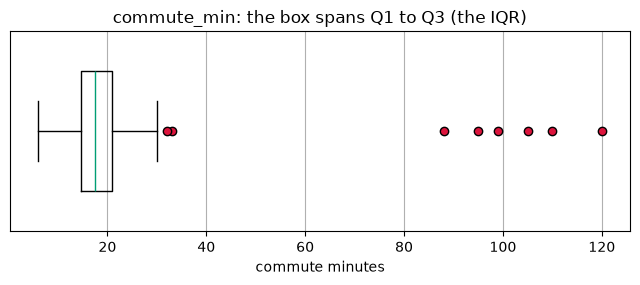

In [31]:
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.boxplot(c, orientation="horizontal", widths=0.6,
           flierprops=dict(marker="o", markerfacecolor="crimson", markersize=6))
ax.set_title("commute_min: the box spans Q1 to Q3 (the IQR)")
ax.set_xlabel("commute minutes"); ax.set_yticks([])
plt.show()

## Variance

The average of the squared distances of each value from the mean. Squaring stops positive
and negative deviations from cancelling, and makes large deviations count much more.

$$\text{population: } \sigma^2 = \frac{1}{N}\sum (x_i - \mu)^2
\qquad
\text{sample: } s^2 = \frac{1}{n-1}\sum (x_i - \bar{x})^2$$

```python
df["exam_score"].var()           # sample (divides by n - 1)
np.var(df["exam_score"])         # population (divides by N)
```

Dividing by $n-1$ for a **sample** corrects a bias that otherwise makes the estimate too
small. Watch the default: **pandas `.var()` uses $n-1$, `np.var` uses $N$** (pass
`ddof=1` to match pandas). Variance is in *squared* units, which is hard to read, so we
usually report the standard deviation instead.

In [32]:
print(f"sample variance     (pandas .var) : {df['exam_score'].var():.1f}")
print(f"population variance  (np.var)      : {np.var(x):.1f}")

sample variance     (pandas .var) : 137.4
population variance  (np.var)      : 136.7


## Standard deviation

The square root of the variance, back in the original units.

$$s = \sqrt{s^2}$$

```python
df["exam_score"].std()           # or  np.std(x, ddof=1)
```

Read it as "the typical distance of a value from the mean". For bell-shaped data there is a
useful rule of thumb, the **68-95-99.7 rule**: about 68% of values fall within 1 standard
deviation of the mean, about 95% within 2, and about 99.7% within 3.

In [33]:
m, sd = x.mean(), x.std()

print(f"standard deviation of exam_score: {sd:.1f}")
print()
for k in (1, 2, 3):
    lo, hi = m - k * sd, m + k * sd
    pct = ((x >= lo) & (x <= hi)).mean() * 100
    print(f"within {k} sd  [{lo:5.1f}, {hi:5.1f}] : {pct:5.1f}% of students")

standard deviation of exam_score: 11.7

within 1 sd  [ 59.8,  83.3] :  67.5% of students
within 2 sd  [ 48.1,  95.0] :  94.5% of students
within 3 sd  [ 36.4, 106.7] : 100.0% of students


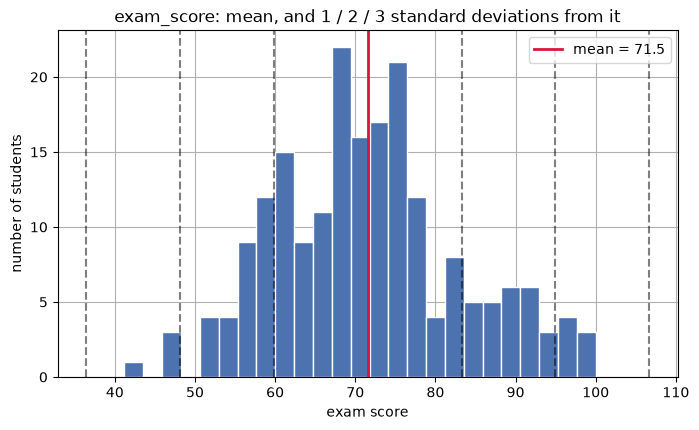

In [34]:
plt.hist(x, bins=25, color="#4C72B0", edgecolor="white")
plt.axvline(m, color="crimson", linewidth=2, label=f"mean = {m:.1f}")
for k in (1, 2, 3):
    plt.axvline(m - k * sd, color="black", linestyle="--", alpha=0.5)
    plt.axvline(m + k * sd, color="black", linestyle="--", alpha=0.5)
plt.title("exam_score: mean, and 1 / 2 / 3 standard deviations from it")
plt.xlabel("exam score"); plt.ylabel("number of students"); plt.legend()
plt.show()

---
# 3. Shape of the data

## Histogram

A histogram splits a numeric column into equal-width **bins** and draws a bar for the count
in each bin.

```python
plt.hist(df["exam_score"], bins=25)
```

It is the fastest way to see the center, spread, and overall shape of one variable, and it
is usually the first chart to make for any new dataset. The number of bins is a choice: too
few hides the shape, too many turns it into noise.

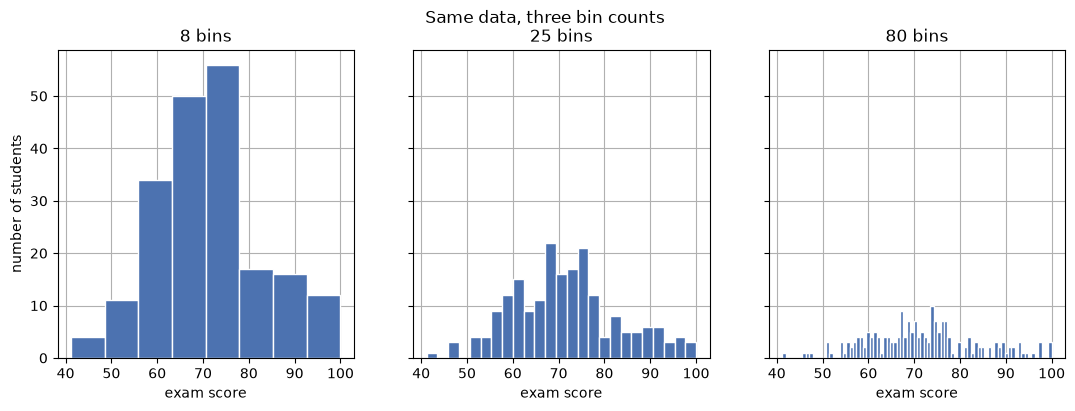

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, bins in zip(axes, [8, 25, 80]):
    ax.hist(x, bins=bins, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{bins} bins"); ax.set_xlabel("exam score")
axes[0].set_ylabel("number of students")
fig.suptitle("Same data, three bin counts")
plt.show()

## Normal distribution

The symmetric "bell curve". It is completely described by two numbers: the mean (its
center) and the standard deviation (its width).

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

```python
# with SciPy:  scipy.stats.norm.pdf(grid, mu, sigma)
# without it:  np.exp(-0.5*((grid - mu)/sigma)**2) / (sigma*np.sqrt(2*np.pi))
```

Many real measurements are close to normal: heights, measurement errors, and averages of
repeated samples. `exam_score` is roughly bell-shaped, so a normal curve built from its own
mean and standard deviation should track the histogram closely.

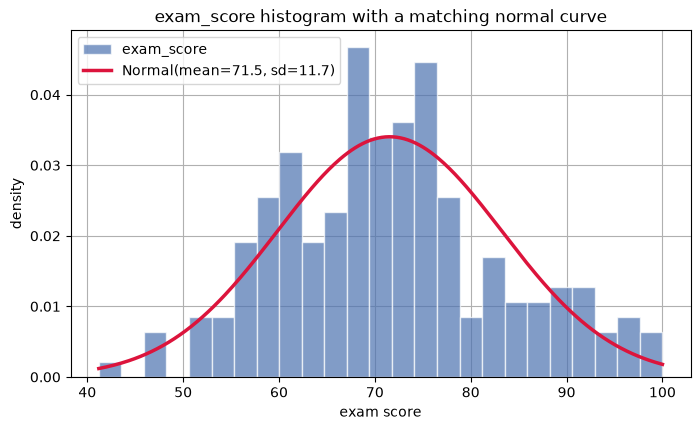

In [43]:
mu, sigma = x.mean(), x.std()
grid = np.linspace(x.min(), x.max(), 300)
pdf = np.exp(-0.5 * ((grid - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

plt.hist(x, bins=25, density=True, color="#4C72B0", edgecolor="white", alpha=0.7,
         label="exam_score")
plt.plot(grid, pdf, color="crimson", linewidth=2.5,
         label=f"Normal(mean={mu:.1f}, sd={sigma:.1f})")
plt.title("exam_score histogram with a matching normal curve")
plt.xlabel("exam score"); plt.ylabel("density"); plt.legend()
plt.show()

## Bimodal distribution

A distribution with **two peaks**. Seeing two humps in a histogram is a signal that the
data may really be two different groups combined, and that a single mean or median would
describe neither of them well.

The histogram of `section_score` for the whole class has two peaks. Splitting the same
column by `section` shows where they come from.

whole class : mean 68.5, median 69.4
section A    : mean 79.7
section B    : mean 57.4


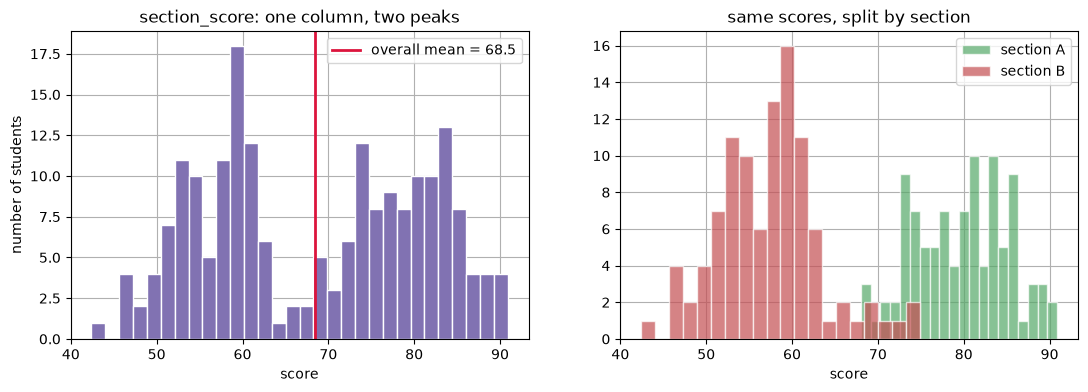

In [44]:
a_scores = df.loc[df["section"] == "A", "section_score"]
b_scores = df.loc[df["section"] == "B", "section_score"]
ss = df["section_score"]

print(f"whole class : mean {ss.mean():.1f}, median {ss.median():.1f}")
print(f"section A    : mean {a_scores.mean():.1f}")
print(f"section B    : mean {b_scores.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ss, bins=30, color="#8172B2", edgecolor="white")
axes[0].axvline(ss.mean(), color="crimson", linewidth=2, label=f"overall mean = {ss.mean():.1f}")
axes[0].set_title("section_score: one column, two peaks")
axes[0].set_xlabel("score"); axes[0].set_ylabel("number of students"); axes[0].legend()

axes[1].hist(a_scores, bins=20, alpha=0.7, label="section A", color="#55A868", edgecolor="white")
axes[1].hist(b_scores, bins=20, alpha=0.7, label="section B", color="#C44E52", edgecolor="white")
axes[1].set_title("same scores, split by section")
axes[1].set_xlabel("score"); axes[1].legend()
plt.show()

## Skewness

A single number that measures how **asymmetric** a distribution is.

- **skew near 0** - symmetric.
- **skew > 0** (right / positive) - a long tail to the right; the mean is greater than the
  median. Typical of study hours, incomes, wait times.
- **skew < 0** (left / negative) - a long tail to the left; the mean is less than the
  median. Typical of an assessment most students do well on.

$$g_1 = \frac{\frac{1}{n}\sum (x_i - \bar{x})^3}{s^3}$$

```python
df["exam_score"].skew()
```

Three columns for comparison: `study_hours` (right), `exam_score` (roughly symmetric), and
`quiz_score` (left: most students score near the top).

In [45]:
q = df["quiz_score"]

print(f"study_hours skew : {h.skew():+.2f}   (right / positive)")
print(f"exam_score  skew : {x.skew():+.2f}   (roughly symmetric)")
print(f"quiz_score  skew : {q.skew():+.2f}   (left / negative)")

study_hours skew : +0.94   (right / positive)
exam_score  skew : +0.29   (roughly symmetric)
quiz_score  skew : -0.79   (left / negative)


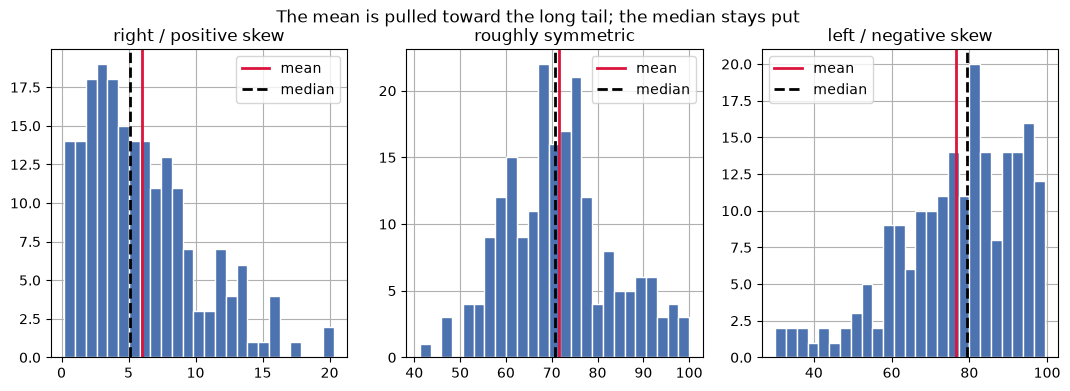

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, series) in zip(axes, [("right / positive skew", h),
                                      ("roughly symmetric", x),
                                      ("left / negative skew", q)]):
    ax.hist(series, bins=25, color="#4C72B0", edgecolor="white")
    ax.axvline(series.mean(), color="crimson", linewidth=2, label="mean")
    ax.axvline(series.median(), color="black", linestyle="--", linewidth=2, label="median")
    ax.set_title(title); ax.legend()
fig.suptitle("The mean is pulled toward the long tail; the median stays put")
plt.show()

## Outliers

Values that sit far away from the rest of the data. An outlier might be a real rare case or
a data-entry mistake, so investigate before removing.

A common test is the **1.5 x IQR rule**: flag a value below $Q_1 - 1.5\,\text{IQR}$ or above
$Q_3 + 1.5\,\text{IQR}$. Those two cutoffs are exactly the "whiskers" of a box plot; points
past them are drawn individually.

```python
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
mask = (x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)
```

Below: apply the rule to `commute_min`. It flags the handful of very large commute times,
plus one or two values only just past the cutoff, a reminder that the rule marks candidates
to review, not a verdict. Then compare how much the outliers move the mean versus the
median.

In [47]:
q1, q3 = np.percentile(c, [25, 75])
iqr = q3 - q1
low_cut, high_cut = q1 - 1.5 * iqr, q3 + 1.5 * iqr

is_outlier = (c < low_cut) | (c > high_cut)
kept = c[~is_outlier]

print(f"cutoffs: below {low_cut:.1f} or above {high_cut:.1f}")
print(f"outliers found ({is_outlier.sum()}): {sorted(c[is_outlier].tolist())}")
print()
print(f"mean  with outliers : {c.mean():.1f}")
print(f"mean  without them  : {kept.mean():.1f}")
print(f"median with / without: {np.median(c):.1f} / {np.median(kept):.1f}  (barely changes)")

cutoffs: below 5.4 or above 30.4
outliers found (8): [32, 33, 88, 95, 99, 105, 110, 120]

mean  with outliers : 19.9
mean  without them  : 17.2
median with / without: 17.5 / 17.0  (barely changes)


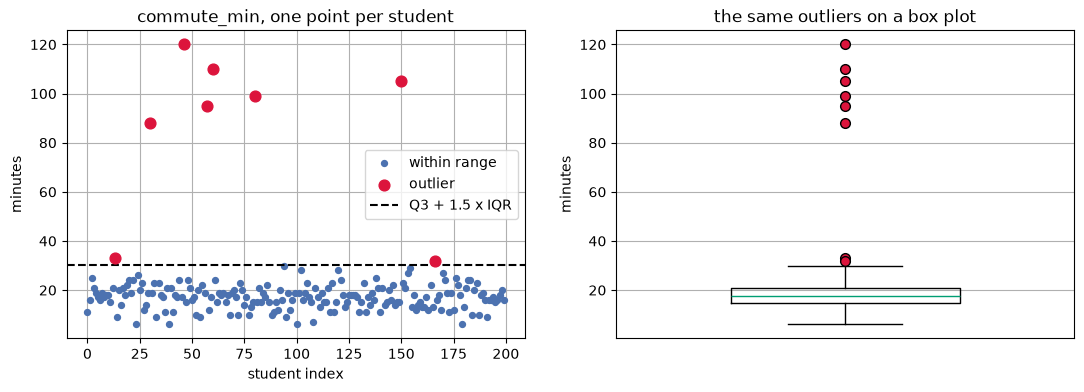

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
idx = np.arange(len(c))

axes[0].scatter(idx[~is_outlier], c[~is_outlier], s=18, color="#4C72B0", label="within range")
axes[0].scatter(idx[is_outlier], c[is_outlier], s=60, color="crimson", zorder=3, label="outlier")
axes[0].axhline(high_cut, color="black", linestyle="--", label="Q3 + 1.5 x IQR")
axes[0].set_title("commute_min, one point per student")
axes[0].set_xlabel("student index"); axes[0].set_ylabel("minutes"); axes[0].legend()

axes[1].boxplot(c, orientation="vertical", widths=0.5,
                flierprops=dict(marker="o", markerfacecolor="crimson", markersize=7))
axes[1].set_title("the same outliers on a box plot")
axes[1].set_ylabel("minutes"); axes[1].set_xticks([])
plt.show()

---
## Summary

| statistic | description | sensitive to outliers? |
|---|---|---|
| mean | the overall average value when every observation counts equally. | yes |
| weighted mean | the average after giving some observations more influence than others. | yes |
| median | the middle of the data, with half the values above it and half below it. | no |
| mode | which value or category occurs most frequently. | no |
| range | the total distance from the smallest value to the largest value. | yes |
| percentile | e value at a particular position in the ordered data. | no |
| IQR | how spread out the middle 50% of the data is. | no |
| variance | the average squared distance of the values from their mean. | yes |
| standard deviation | the typical distance of values from the mean, in the original units. | yes |
| skewness | whether the data leans toward a longer right or left tail, or is fairly symmetric. | - |
| outlier rule | which values are unusually far from the middle 50% and should be investigated. | - |

**General Rules**

- Symmetric data: describe it with the mean and standard deviation.
- Skewed data, or outliers present: use the median and IQR instead.
- Two peaks in the histogram: look for a grouping variable; you likely have two groups.
- Draw the histogram first.